# Combined Denoising + Regression Model: Evaluation

This notebook evaluates a trained `LitS4CombinedModel` (the `S4DCombinedModel` architecture)
which jointly performs:
1. **Denoising** – `S4DSeq2SeqModel` maps a noisy I/Q sequence to a denoised sequence
2. **Regression** – `S4DModel` reads the denoised sequence and predicts energy + pitch angle

Batches produced by `LitCombinedDataModule` have the form `(x_noisy, x_clean, y, obs)`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import yaml
from scipy import signal as sp_signal

from src.models.model import LitS4CombinedModel
from src.models.networks import S4DCombinedModel
from src.data.data import LitCombinedDataModule

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

/n/holystore01/LABS/iaifi_lab/Users/creissel/miniforge/envs/ssm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 1. Configuration

Set the path to your checkpoint. The config is expected one level above the `lightning_logs/` directory (i.e. `../../config.yaml` relative to the run folder), matching the standard training layout.

In [2]:
# ── Update this path ──────────────────────────────────────────────────────────
path            = '/n/home03/creissel/neutrino_project/runs/combined_ts_inputIQ_iterativeTraining_withUnc_Cuts_Replay/Project8/a0s8ga0s/'
CHECKPOINT_PATH = os.path.join(path, 'checkpoints/last.ckpt')
#CHECKPOINT_PATH = os.path.join(path, 'checkpoints/epoch=107-step=130464.ckpt')
CONFIG_PATH     = os.path.join(path, '../../config.yaml')
# ─────────────────────────────────────────────────────────────────────────────

## 2. Load Data Module from Checkpoint

In [3]:
dm = LitCombinedDataModule.load_from_checkpoint(CHECKPOINT_PATH)
test_loader = dm.test_dataloader()
print(f'Test batches  : {len(test_loader)}')

Test batches  : 151


## 3. Load Model from Checkpoint

In [4]:
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

model = LitS4CombinedModel.load_from_checkpoint(CHECKPOINT_PATH)
model = model.to(device).eval()

/n/holystore01/LABS/iaifi_lab/Users/creissel/miniforge/envs/ssm/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['encoder'])`.


## 4. Visualise Example Inputs

Plot a few noisy / clean pairs straight from the dataloader.

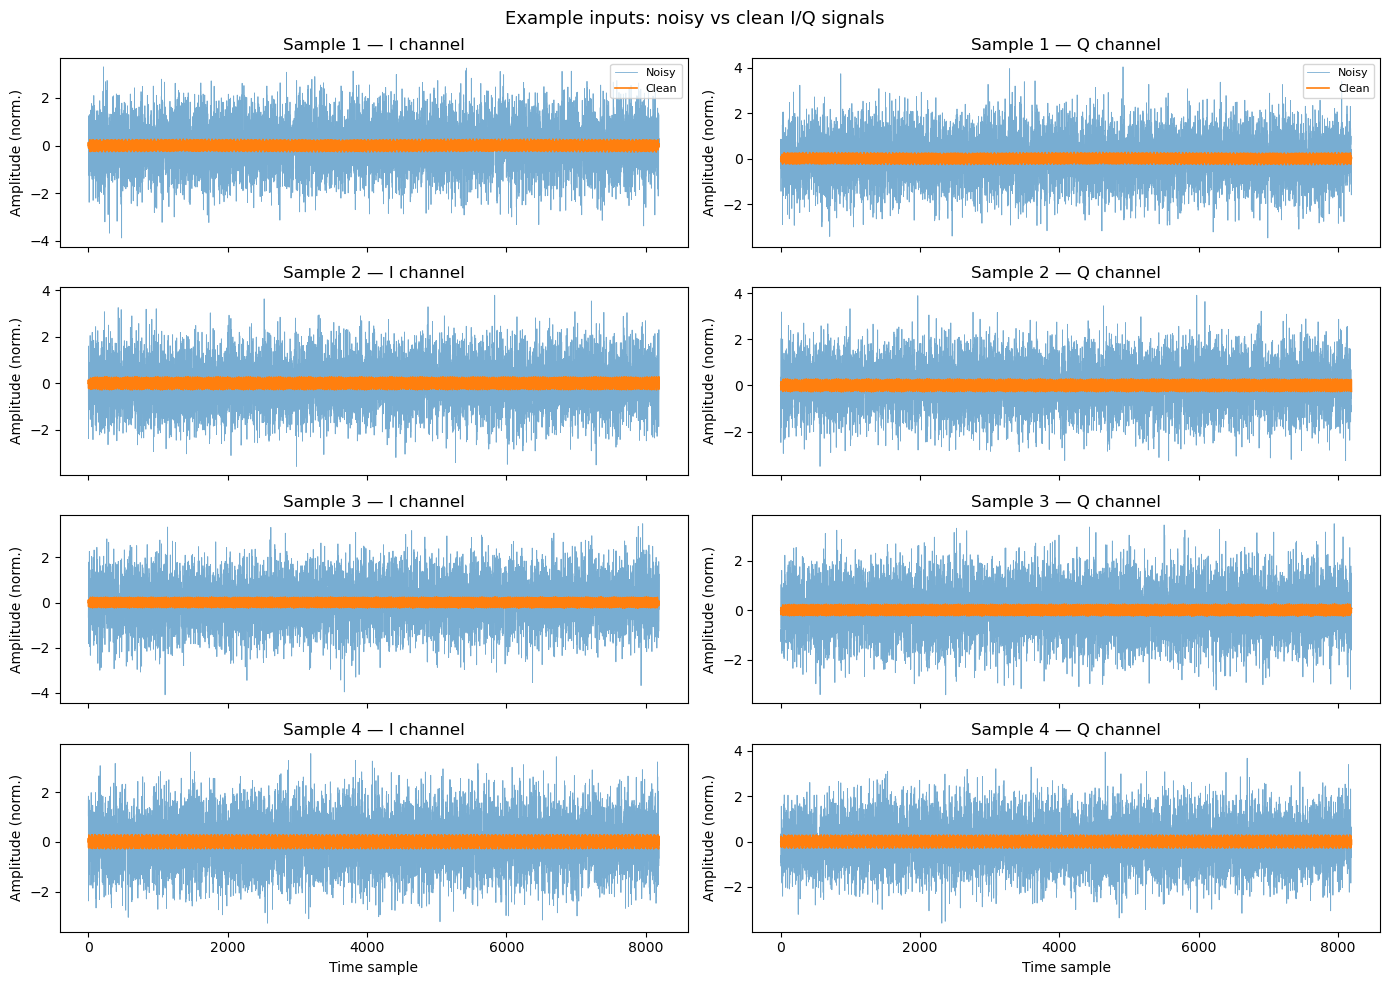

In [5]:
N_EXAMPLES = 4
CHANNEL_LABELS = ['I channel', 'Q channel']

x_noisy_batch, x_clean_batch, y_batch, obs_batch = next(iter(test_loader))
cutoff = x_noisy_batch.shape[1]
t = np.arange(cutoff)

fig, axes = plt.subplots(N_EXAMPLES, 2, figsize=(14, 2.5 * N_EXAMPLES), sharex=True)

for i in range(N_EXAMPLES):
    for ch, label in enumerate(CHANNEL_LABELS):
        ax = axes[i, ch]
        ax.plot(t, x_noisy_batch[i, :, ch].numpy(), color='tab:blue',   alpha=0.6, lw=0.6, label='Noisy')
        ax.plot(t, x_clean_batch[i, :, ch].numpy(), color='tab:orange', lw=1.2,            label='Clean')
        ax.set_ylabel('Amplitude (norm.)')
        ax.set_title(f'Sample {i+1} — {label}')
        if i == 0:
            ax.legend(loc='upper right', fontsize=8)

axes[-1, 0].set_xlabel('Time sample')
axes[-1, 1].set_xlabel('Time sample')
fig.suptitle('Example inputs: noisy vs clean I/Q signals', fontsize=13)
fig.tight_layout()
plt.show()

## 5. Run the Model and Visualise Denoising Predictions

/n/holystore01/LABS/iaifi_lab/Users/creissel/miniforge/envs/ssm/lib/python3.10/site-packages/torch/nn/functional.py:1381: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn("dropout2d: Received a 3D input to dropout2d and assuming that channel-wise "


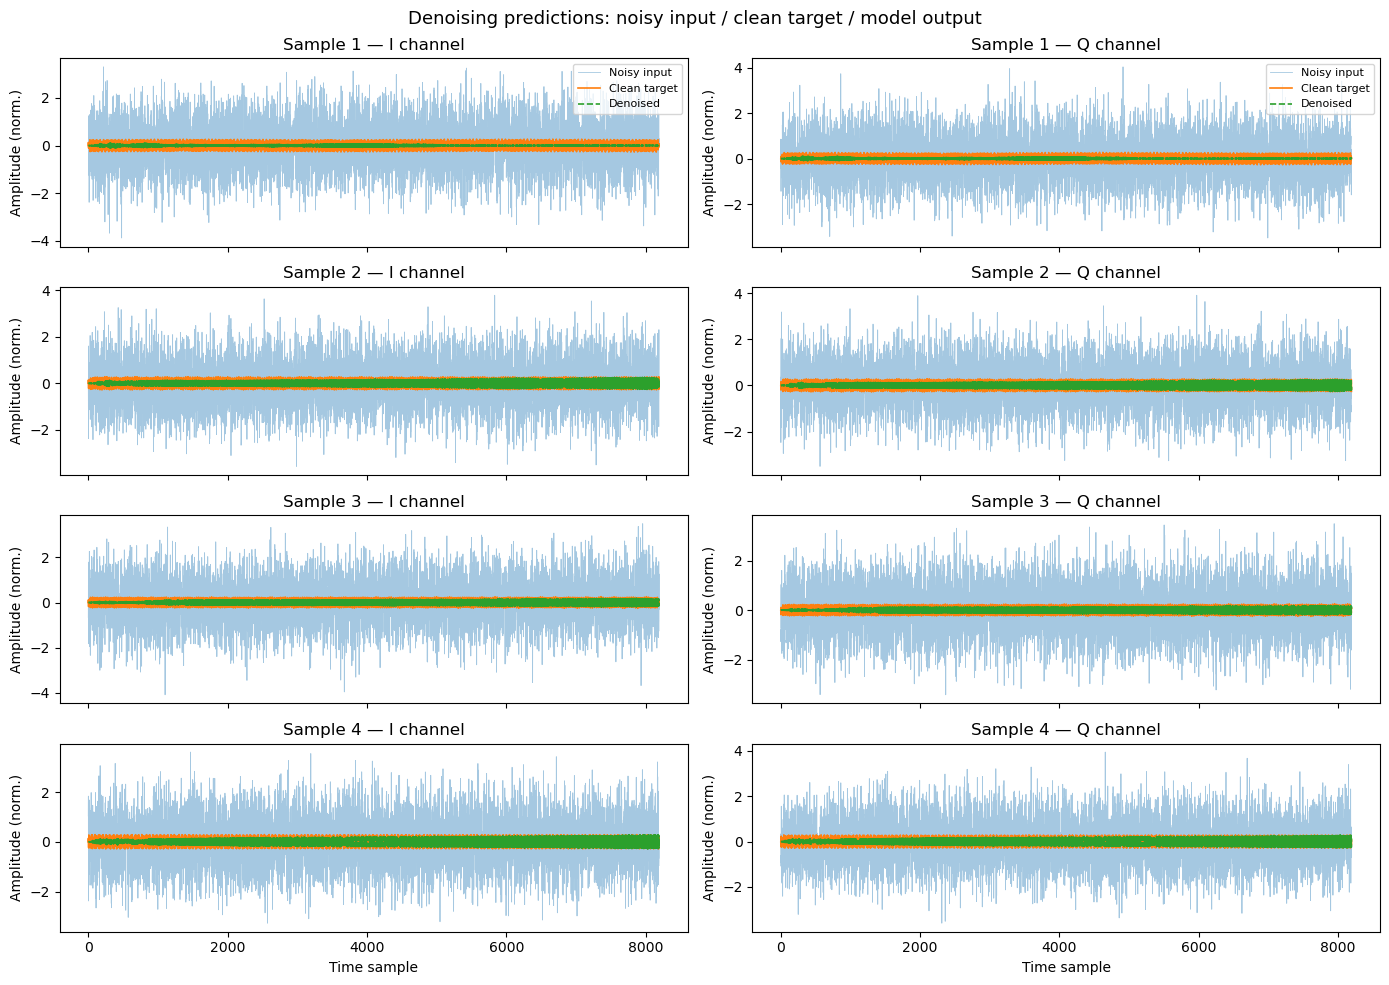

In [6]:
with torch.no_grad():
    x_denoised_batch, y_pred_batch = model(x_noisy_batch.to(device))
    x_denoised_batch = x_denoised_batch.cpu()
    y_pred_batch     = y_pred_batch.cpu()

fig, axes = plt.subplots(N_EXAMPLES, 2, figsize=(14, 2.5 * N_EXAMPLES), sharex=True)

for i in range(N_EXAMPLES):
    for ch, label in enumerate(CHANNEL_LABELS):
        ax = axes[i, ch]
        ax.plot(t, x_noisy_batch[i, :, ch].numpy(),    color='tab:blue',   alpha=0.4, lw=0.6, label='Noisy input')
        ax.plot(t, x_clean_batch[i, :, ch].numpy(),    color='tab:orange', lw=1.2,            label='Clean target')
        ax.plot(t, x_denoised_batch[i, :, ch].numpy(), color='tab:green',  lw=1.2, ls='--',   label='Denoised')
        ax.set_ylabel('Amplitude (norm.)')
        ax.set_title(f'Sample {i+1} — {label}')
        if i == 0:
            ax.legend(loc='upper right', fontsize=8)

axes[-1, 0].set_xlabel('Time sample')
axes[-1, 1].set_xlabel('Time sample')
fig.suptitle('Denoising predictions: noisy input / clean target / model output', fontsize=13)
fig.tight_layout()
plt.show()

## 6. Zoom In on a Signal Region

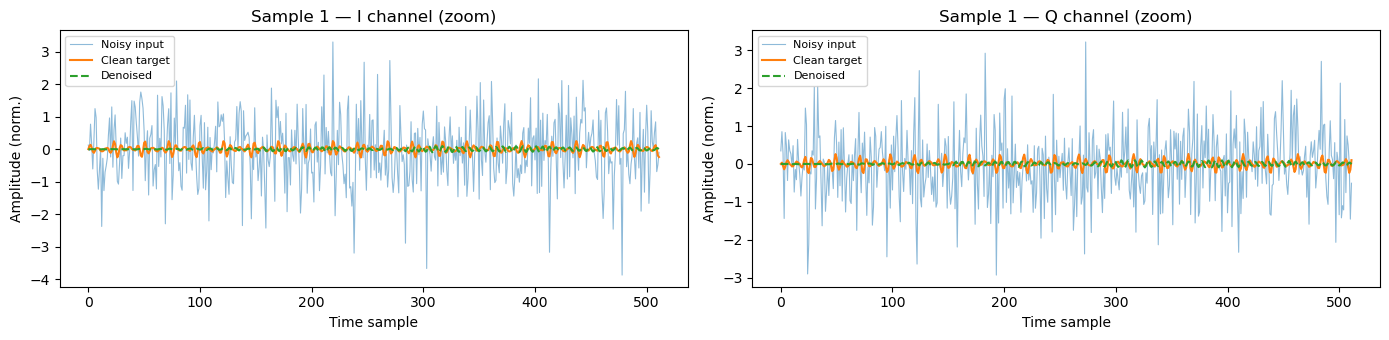

In [7]:
WINDOW_START = 0
WINDOW_LEN   = 512
SAMPLE_IDX   = 0

sl     = slice(WINDOW_START, WINDOW_START + WINDOW_LEN)
t_zoom = np.arange(WINDOW_START, WINDOW_START + WINDOW_LEN)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

for ch, label in enumerate(CHANNEL_LABELS):
    ax = axes[ch]
    ax.plot(t_zoom, x_noisy_batch[SAMPLE_IDX, sl, ch].numpy(),    color='tab:blue',   alpha=0.5, lw=0.8, label='Noisy input')
    ax.plot(t_zoom, x_clean_batch[SAMPLE_IDX, sl, ch].numpy(),    color='tab:orange', lw=1.5,            label='Clean target')
    ax.plot(t_zoom, x_denoised_batch[SAMPLE_IDX, sl, ch].numpy(), color='tab:green',  lw=1.5, ls='--',   label='Denoised')
    ax.set_xlabel('Time sample')
    ax.set_ylabel('Amplitude (norm.)')
    ax.set_title(f'Sample {SAMPLE_IDX+1} — {label} (zoom)')
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 7. Power Spectral Density Comparison

Compare the PSD of the noisy input, clean target, and denoised prediction.

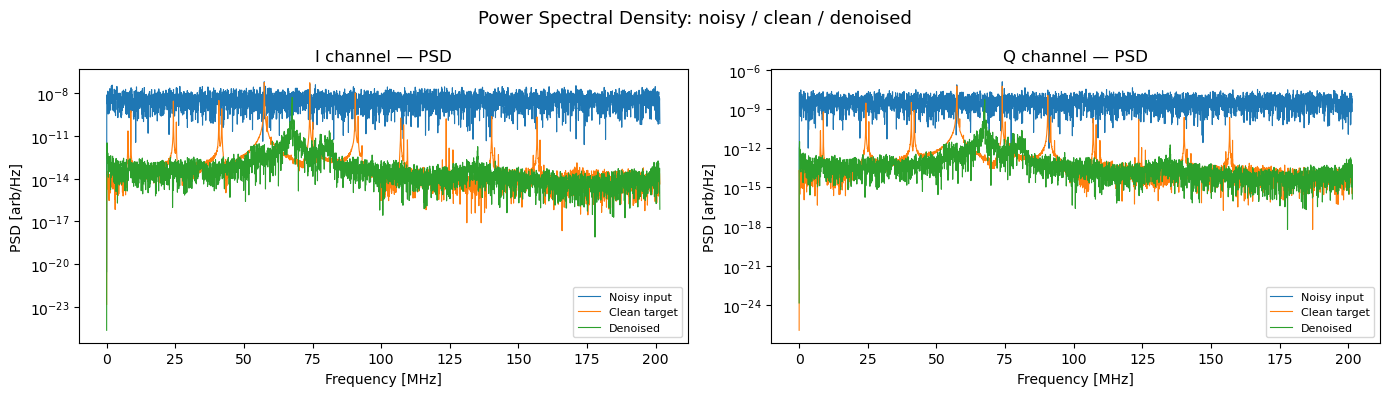

In [8]:
FS = 403e6  # sampling frequency in Hz

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ch, label in enumerate(CHANNEL_LABELS):
    ax = axes[ch]
    for sig, name, color in [
        (x_noisy_batch[SAMPLE_IDX, :, ch].numpy(),    'Noisy input',  'tab:blue'),
        (x_clean_batch[SAMPLE_IDX, :, ch].numpy(),    'Clean target', 'tab:orange'),
        (x_denoised_batch[SAMPLE_IDX, :, ch].numpy(), 'Denoised',     'tab:green'),
    ]:
        f, pxx = sp_signal.periodogram(sig, fs=FS)
        ax.semilogy(f / 1e6, pxx, lw=0.8, label=name, color=color)
    ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('PSD [arb/Hz]')
    ax.set_title(f'{label} — PSD')
    ax.legend(fontsize=8)

fig.suptitle('Power Spectral Density: noisy / clean / denoised', fontsize=13)
fig.tight_layout()
plt.show()

## 8. Run Full Test Set — Collect Predictions

Iterate over the full test dataloader to collect denoising MSE and regression predictions.

In [9]:
import tqdm

true_list    = []
pred_list    = []
meta_list    = []
mse_list     = []
max_powers   = []
summed_powers= []

for x_noisy, x_clean, y, obs in tqdm.tqdm(test_loader, desc='Evaluating'):
    with torch.no_grad():
        x_denoised, y_pred = model(x_noisy.to(device))
        x_denoised = x_denoised.cpu()
        y_pred     = y_pred.cpu()

    true_list.append(y.numpy())
    pred_list.append(y_pred.numpy())
    meta_list.append(obs.numpy())

    # Per-sample denoising MSE (mean over L and C)
    mse = ((x_denoised - x_clean) ** 2).mean(dim=(1, 2))
    mse_list.append(mse.numpy())

    # PSD-based power features from the noisy time series
    for i in range(x_noisy.shape[0]):
        f_i, pxx_i = sp_signal.periodogram(x_noisy[i, :, 0].numpy(), fs=FS)
        f_q, pxx_q = sp_signal.periodogram(x_noisy[i, :, 1].numpy(), fs=FS)
        pxx_sum = pxx_i + pxx_q
        noise_floor = np.sum(pxx_sum[:400]) + 1e-30
        normed = pxx_sum / noise_floor
        max_powers.append(normed.max())
        summed_powers.append(normed.sum())

Evaluating: 100%|██████████| 151/151 [01:14<00:00,  2.04it/s]


In [10]:
true_all        = np.concatenate(true_list,  axis=0)
pred_all        = np.concatenate(pred_list,  axis=0)
meta_all        = np.concatenate(meta_list,  axis=0)
mse_all         = np.concatenate(mse_list)
max_powers      = np.array(max_powers)
summed_powers   = np.array(summed_powers)

print(f'Test samples: {len(true_all)}')

Test samples: 9660


In [14]:
pred_all = pred_all[:,:-2]

In [15]:
pred_all.shape

(9660, 2)

In [16]:
# undo the normalization
print(dm.stds)
print(dm.mu)
pred_post = pred_all * dm.stds + dm.mu
true_post = true_all * dm.stds + dm.mu

[57.706432    0.57697964]
[18600.217      88.99479]


In [17]:
image_folder = os.path.join(path, 'results')
! mkdir "{image_folder}"

/n/home03/creissel/neutrino_project/runs/combined_ts_inputIQ_iterativeTraining_withUnc_Cuts_Replay/Project8/a0s8ga0s/results


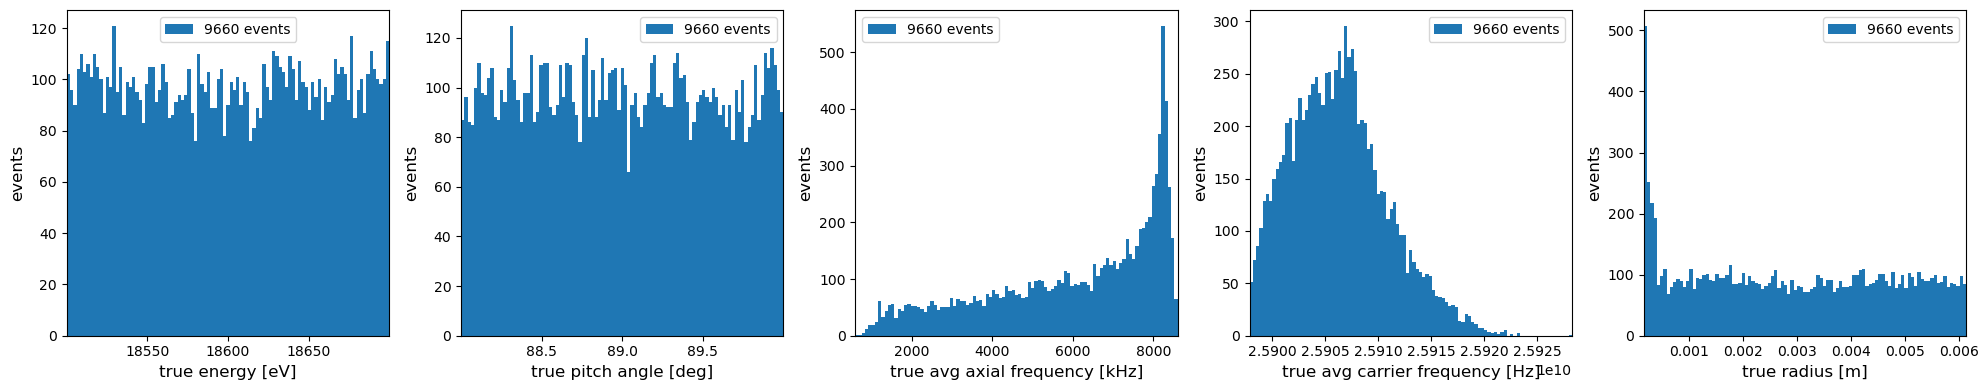

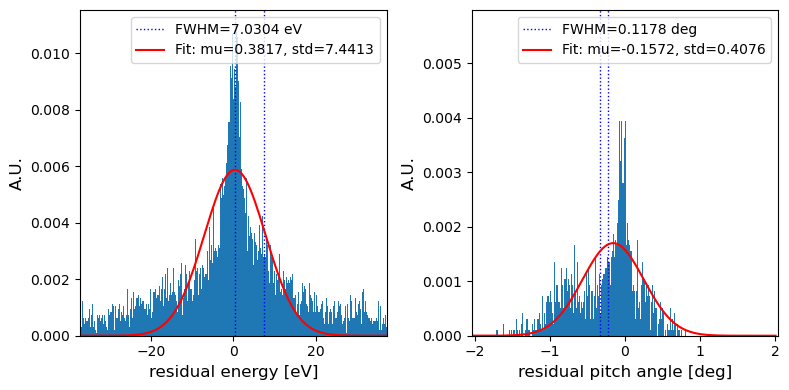

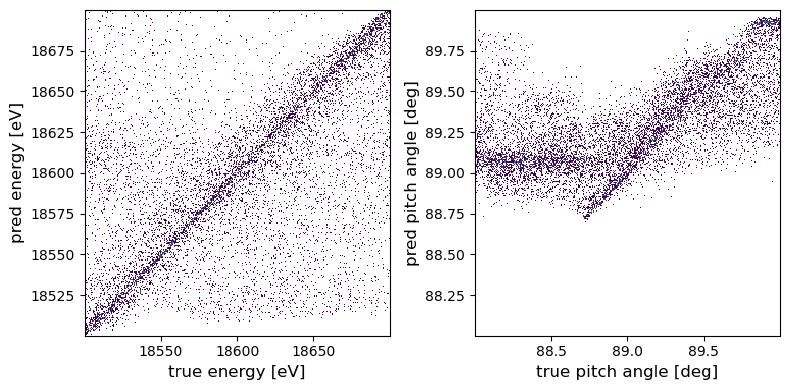

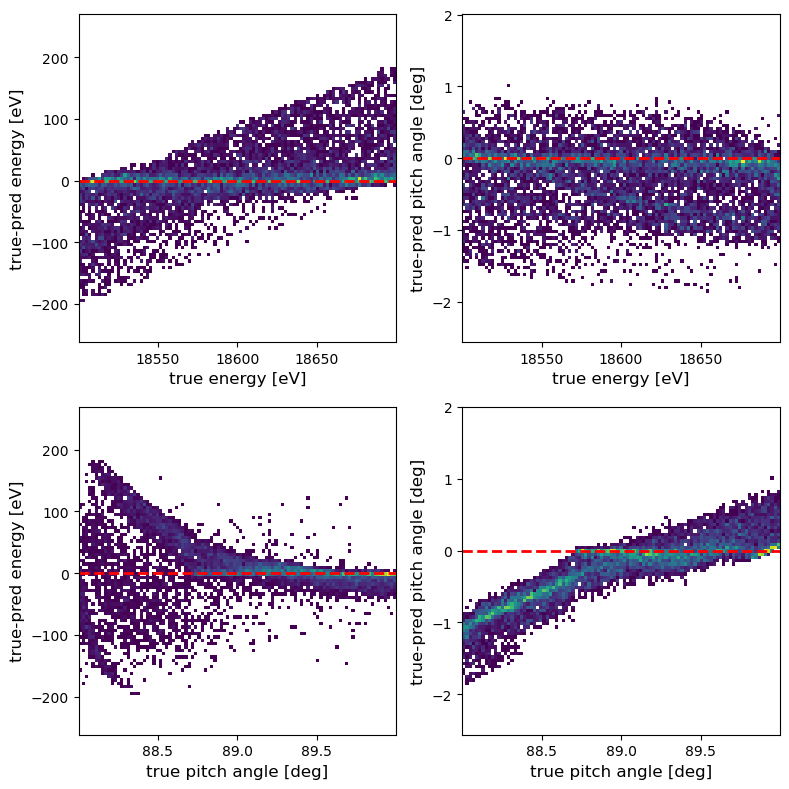

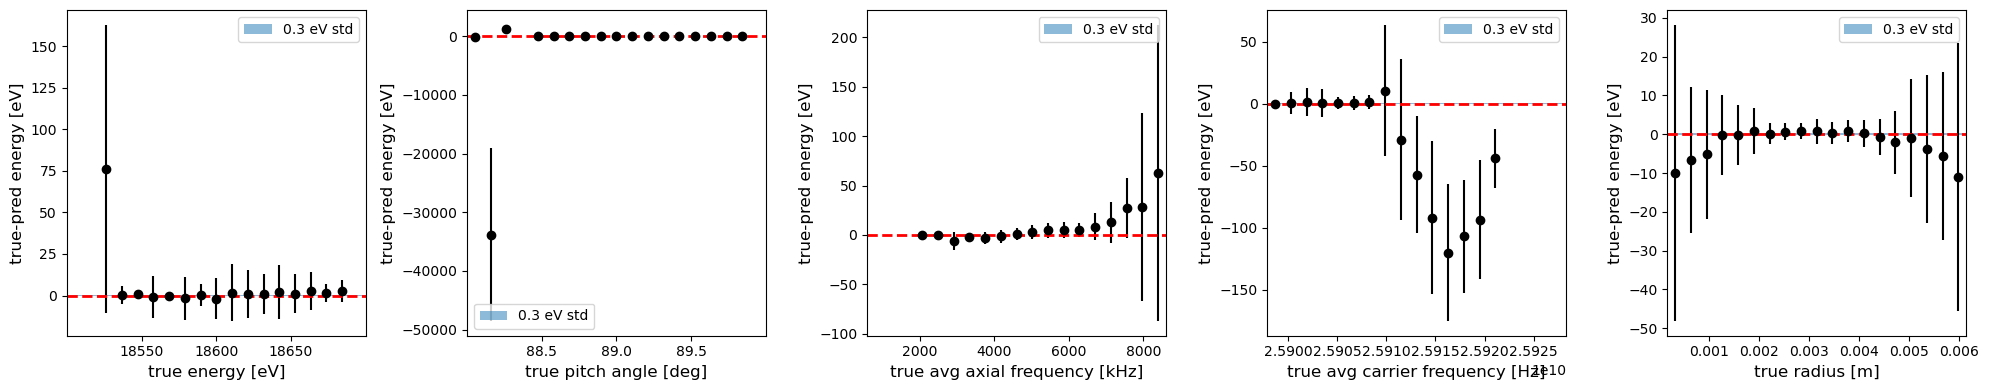

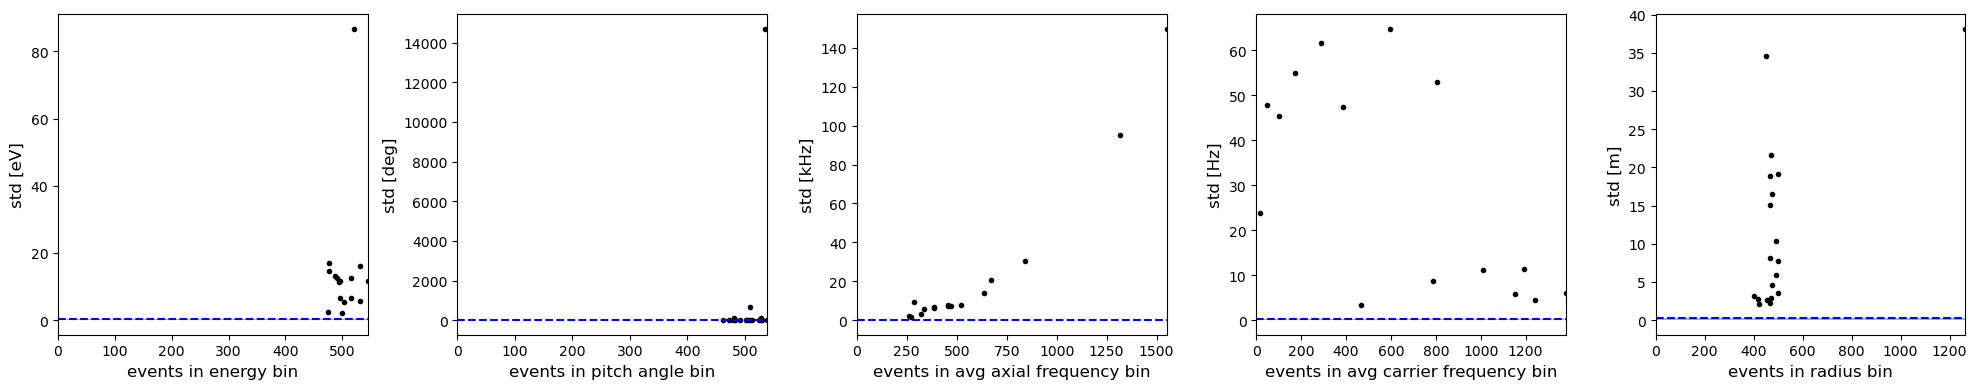

In [18]:
from src.utils.plotting import *
f = make_all_plots(dm.variables, dm.observables,true_post, pred_post, meta_all, folder=image_folder, savefigs=True, fit_gaussian=True)